# Financial Trading with Python, 2nd Edition
**Author:** Cordell L. Tanny, CFA, FRM, FDP

**Chapter 15:** Machine Learning in Practice

**Notebook:** B37124_15_01_ml_in_practice

**Version:** 1.0

**Date:** July 2026

*Strategy notebook: running the full ML process on a real problem, and letting the gates decide.*

> Save a copy to your own Drive before running (File → Save a copy in Drive).

## 0. Setup

In *Chapter 14, Deciding When to Reach for Machine Learning*, we built four gates and watched what model complexity costs on data where we knew the true answer. This notebook spends that framework on a real problem, with real prices, where nobody knows the true answer.

The question we ask is a practical one. Can a model tell us, at today's close, that tomorrow SPY falls more than 2%? If it can, we have something worth trading: we cut equity exposure ahead of the drop and move into treasuries, then step back in. Sharp single-day declines are the ones that do the most damage to a portfolio, so a warning that arrives even slightly early has obvious value.

We will run the full six-step process from Chapter 14 on that question, without shortcuts. We build features, split the data chronologically, fit a logistic regression as the bar the model has to clear, fit the Random Forest, bring in an AutoML tool as a second opinion, look at what the model actually learned, convert its probabilities into portfolio weights, and backtest the result against a benchmark that uses no model at all.

I am going to tell you the ending now, because the ending is the lesson. The model finds real signal, and the gates still point back to the simple linear baseline. A fixed allocation that requires no model, no features, and no maintenance matches everything we build here. That is not a failure of the process. That is the process working, delivering a verdict before any money is at risk, which is exactly what it is for.

Setup runs in two parts. First we pin package versions and restart the runtime, because several of these libraries change their behavior between releases and a Sharpe ratio that moves with a version number is not a result you can reason about. Then we pull two helper files from the book repository and import everything the notebook needs.

### Pinning the environment

Version drift is a real problem in backtesting. VectorBT, scikit-learn, and FLAML each change behavior between releases, so a result that shifts with a version number cannot be reasoned about or reproduced. These pins match the rest of the book, which means the backtest machinery here behaves identically to *Chapter 13, Novel Uses of Established Techniques*.

What we install and why:

- **`numpy==2.0.2` and `pandas==2.2.2`:** the numerical and data-handling base used throughout the book.
- **`vectorbt==0.28.5`:** the backtesting engine. This is the version the book's backtest harness was tested against.
- **`yfinance==0.2.54`:** the price data source.
- **`scikit-learn==1.5.2`:** the logistic regression, the Random Forest, and the scaling and scoring tools.
- **`flaml[automl]==2.3.2`:** the automated machine learning tool we use later as a second opinion on model choice.

Colab ships with its own versions of several of these, so the install replaces them. That replacement only takes effect after a runtime restart, which is why this cell asks you to restart before going further. Nothing below will import correctly until you do.

In [17]:
# Pinned versions, matching the rest of the book so results are reproducible.
# Colab already has some of these installed, so pip replaces them in place.
# The replacements are not active until the runtime restarts.
!pip install -q numpy==2.0.2 pandas==2.2.2 vectorbt==0.28.5 yfinance==0.2.54 \
    scikit-learn==1.5.2 "flaml[automl]==2.3.2" 2>&1 | tail -5

print("Installs complete.")
print("RESTART THE RUNTIME NOW: Runtime > Restart session, then continue below.")

Installs complete.
RESTART THE RUNTIME NOW: Runtime > Restart session, then continue below.


The install finished, but pip reported two conflicts in red:

- **`hdbscan 0.8.44`** and **`umap-learn 0.5.12`** both want scikit-learn 1.6 or newer, and we pinned 1.5.2.

Neither package is imported anywhere in this notebook. They come preinstalled in Colab for clustering work unrelated to what we are doing, so the conflict has no effect on any result here.

Two things worth taking from this:

- **Pip reports on the whole environment, not just your request.** It checks every package already installed against the ones you asked for, so red text often describes a problem you do not have. A failed install says so plainly, usually with the words `ERROR: Could not find a version` or a traceback.
- **The check that matters is what actually loaded.** Version numbers printed by the running session are the only proof that the pins took effect, which is what the next cell does.

We stay on scikit-learn 1.5.2 rather than upgrading, because every model result in this book was produced on that version. Matching it means the numbers you see here are the numbers you can reproduce.

### Confirming the versions loaded

Installing a package and loading it are separate events. Until the runtime restarts, Colab keeps serving the versions it started with, so a notebook can install one version of a library and quietly run on another. This cell prints what the session is actually using.

Check the printed numbers against the pins:

- **numpy:** 2.0.2
- **pandas:** 2.2.2
- **vectorbt:** 0.28.5
- **scikit-learn:** 1.5.2

If any of these disagree, the restart did not take effect. Run **Runtime > Restart session** and start again from this cell rather than continuing, since a version mismatch here will show up later as backtest numbers that do not match the book.

In [18]:
# Run this AFTER restarting the runtime.
# Importing a package reports the version the session actually loaded,
# which is not always the version pip just installed.
import numpy as np
import pandas as pd
import vectorbt as vbt
import sklearn
import flaml

print('numpy      ', np.__version__)
print('pandas     ', pd.__version__)
print('vectorbt   ', vbt.__version__)
print('scikit-learn', sklearn.__version__)
print('flaml      ', flaml.__version__)

numpy       2.0.2
pandas      2.2.2
vectorbt    0.28.5
scikit-learn 1.5.2
flaml       2.3.2


Every version matches:

- **numpy 2.0.2, pandas 2.2.2, vectorbt 0.28.5, scikit-learn 1.5.2, flaml 2.3.2**

The restart worked, and the session is running on the same versions the book was written against. The conflict warnings from the install cell can be set aside, since the packages they named are not part of this notebook.

From here, any result you get should match the results printed in the chapter. If a number ever comes out different, this cell is the first place to check.

### Loading the book's toolkit

Two files come from the book's GitHub repository rather than being rewritten here:

- **`functions.py`:** the performance measurement toolkit from *Chapter 7, Strategy Evaluation*. It calculates returns, volatility, drawdown, Sharpe, and the rest of the metrics we score every strategy on.
- **`vectorbt_harness_no_yf.py`:** the backtest harness from *Chapter 13, Novel Uses of Established Techniques*. It takes a file of dated portfolio weights and turns it into a costed backtest with a benchmark comparison.

Downloading them keeps this notebook consistent with every other backtest in the book. The same code scores the strategy here that scored the strategies in earlier chapters, so the comparison across chapters is a fair one, and none of the machinery has been quietly adjusted to flatter this result.

The harness matters more than it looks. It applies trading costs, it aligns weights to the trading calendar, and it scores results on monthly returns using the Chapter 7 metrics. All of that is written once and reused, which removes a whole category of mistakes that come from rebuilding a backtest for each new strategy.

This cell also brings in everything else the notebook needs and sets plotting defaults that keep figures readable in print.

In [19]:
# --- Fetch the book's shared modules ---
# functions.py            : Chapter 7 performance metrics
# vectorbt_harness_no_yf.py : Chapter 13 backtest harness, prices passed in as an argument
REPO = ('https://raw.githubusercontent.com/PacktPublishing/'
        'Hands-on-Financial-Trading-with-Python-Second-Edition/main/FINAL/python_scripts')

!wget -q -O functions.py {REPO}/functions.py
!wget -q -O vectorbt_harness_no_yf.py {REPO}/vectorbt_harness_no_yf.py

import os
for f in ['functions.py', 'vectorbt_harness_no_yf.py']:
    print(f'{f:28s} {os.path.getsize(f):>7,d} bytes')

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from flaml import AutoML

# --- Quieten the noise ---
# FLAML logs every model it tries during its search, which runs to hundreds of
# lines. We keep errors visible and suppress the running commentary.
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('flaml').setLevel(logging.ERROR)

# --- Display and plotting defaults ---
# Wide frames print without wrapping, and figures stay readable in greyscale.
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('\nToolkit loaded and imports complete.')

functions.py                  12,491 bytes
vectorbt_harness_no_yf.py     25,152 bytes

Toolkit loaded and imports complete.


Both files downloaded and every import resolved:

- **`functions.py`:** 12,491 bytes
- **`vectorbt_harness_no_yf.py`:** 25,152 bytes

The byte counts are worth a glance rather than a skip. When a repository path is wrong, `wget` still writes a file, but it writes the error page it received instead of the code you wanted, and that file is usually only a few hundred bytes. A size in the thousands means real code arrived. The failure would otherwise stay hidden until an import fails several sections later, at which point the cause is much harder to trace.

The environment is now fixed and the toolkit is loaded. Everything from here runs on known versions with shared, reused scoring code.

## 1. Parameters

Every choice this notebook makes lives in one place, so you can change a setting once and re-run without hunting through code. Nothing below hard-codes any of these values.

The settings fall into five groups:

- **Data:** which tickers to pull and over what dates.
- **Feature windows:** the lookback lengths used to build inputs.
- **Target:** what counts as the event we are trying to predict.
- **Split and models:** where the training data ends, and how each model is configured.
- **Evaluation and strategy conversion:** how models are compared, and how a probability becomes a portfolio weight.

Two of these deserve a note now, since they shape everything that follows.

The **target** is a next-day SPY return below -2%. We tested several definitions during research, including longer horizons and larger drops, and settled on this one because it carried the strongest signal while still producing enough events to measure. Rarer events give a model too little to learn from, and we return to that point when we count them in section 4.

The **split date** of 2018-12-31 is chronological, with no shuffling. Market data arrives in time order, and a model that trains on 2022 to predict 2019 has seen the future. Everything from 2019 onward stays untouched until the model is finished.

The strategy conversion settings at the bottom will not mean much yet. We arrive at them in section 11, and the reasoning behind each one is explained there rather than assumed here.

In [20]:
# ============================================================================
# All user-set values live here. Change once, re-run, nothing below is hard-coded.
# ============================================================================

# --- Data ---
TICKERS = ['SPY', 'GLD', 'IEF', 'XLF', '^VIX']
START   = '2004-01-01'   # requested start; GLD's Nov 2004 inception is what actually binds
END     = '2026-07-01'

# --- Feature windows (trading days) ---
ROLL_SHORT = 5     # short realized volatility
ROLL_MED   = 25    # deviation from recent average
ROLL_LONG  = 60    # z-scores, where a longer window gives a stabler reference

# --- Target: forward return over HORIZON days below THRESHOLD ---
HORIZON   = 1
THRESHOLD = -0.020   # a 2% down day

# --- Split ---
TRAIN_END = '2018-12-31'   # chronological, no shuffling

# --- Models ---
# class_weight='balanced' matters on a rare target. Without it a model scores well
# by calling every day safe, which is accurate and useless.
# min_samples_leaf=20 stops the trees carving out leaves built on a handful of days.
RF_PARAMS = dict(n_estimators=500, min_samples_leaf=20, max_features='sqrt',
                 class_weight='balanced', random_state=17, n_jobs=-1)
FLAML_BUDGET = 120   # seconds the AutoML search is allowed to run

# --- Evaluation ---
FLAG_RATE = 0.10   # compare models by their riskiest 10% of days, not a fixed cutoff

# --- Strategy conversion (explained in section 11) ---
RISK_OFF       = 0.50            # probability above this trips the risk-off signal
HOLD_DAYS      = 5               # days to hold the de-risked stance
SPY_WEIGHT_OFF = 0.60            # SPY weight while risk-off, remainder to IEF
STATIC_WEIGHTS = [0.85, 0.88, 0.90]   # constant-allocation benchmark grid

print('Parameters set.')
print(f'Tickers   : {TICKERS}')
print(f'Target    : SPY return below {THRESHOLD:.1%} over {HORIZON} day(s)')
print(f'Train ends: {TRAIN_END}')

Parameters set.
Tickers   : ['SPY', 'GLD', 'IEF', 'XLF', '^VIX']
Target    : SPY return below -2.0% over 1 day(s)
Train ends: 2018-12-31


The three printed lines confirm the settings that matter most:

- **Tickers:** SPY, GLD, IEF, XLF, and the VIX.
- **Target:** an SPY return below -2.0% over one day.
- **Training data ends:** 2018-12-31.

Read that target line as the question the model is being asked. Every model, every score, and every trade in this notebook traces back to it, so if you change `THRESHOLD` or `HORIZON` later, expect everything downstream to move with it.

## 2. Data

Five tickers come down from Yahoo Finance, and they do two different jobs:

- **SPY:** the asset we trade, and the benchmark we measure against.
- **IEF:** a treasury bond fund, and the asset we move into when the model signals danger.
- **GLD, XLF, and the VIX:** used only to build model inputs. We never hold them.

That split matters, so we build two separate price frames rather than one:

- **`feat_px`:** all five closes, used to construct features.
- **`bt_prices`:** SPY and IEF only, passed to the backtest harness.

Keeping them apart stops the backtest inheriting a start date from a ticker the strategy never holds. GLD did not exist before November 2004, and once we require all five series on the same day, the feature panel cannot start any earlier. There is no reason for that to constrain a portfolio holding SPY and IEF.

Two settings in the download deserve attention:

- **`auto_adjust=True`:** the `Close` column comes back adjusted for dividends and splits, and there is no separate `Adj Close` column. Unadjusted prices show a false drop on every dividend date, which a model happily learns as signal.
- **Volume for SPY and XLF only:** the VIX is an index and has no volume, while GLD and IEF volume added inputs that carried no weight during testing.

In [21]:
# ============================================================================
# Download prices and build the two frames the notebook needs.
# ============================================================================

# auto_adjust=True returns dividend- and split-adjusted closes, so there is no
# separate 'Adj Close' column. Unadjusted prices dip on every ex-dividend date,
# which a model will happily mistake for a real return.
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True,
                  progress=False, group_by='column')

# --- Feature frame: all five closes ---
# dropna() keeps only days where every series traded, so the features are always
# built from a complete cross-section. GLD's November 2004 inception is what sets
# the start date once that intersection is applied.
feat_px = raw['Close'].copy().dropna()
feat_px.columns = [c.replace('^', '') for c in feat_px.columns]   # '^VIX' -> 'VIX'

# --- Volume, kept only where it is meaningful ---
# The VIX is an index and has no volume. GLD and IEF volume added no value in testing.
VOLUME_TICKERS = ['SPY', 'XLF']
vol = raw['Volume'].copy()
vol.columns = [c.replace('^', '') for c in vol.columns]
vol = vol[VOLUME_TICKERS].reindex(feat_px.index)

# --- Backtest frame: the traded universe only ---
# Built from the raw download rather than from feat_px, so the backtest keeps its
# full history instead of inheriting GLD's start date.
bt_prices = raw['Close'][['SPY', 'IEF']].copy().dropna()

print(f'Features : {feat_px.shape[0]:,} rows x {feat_px.shape[1]} columns, '
      f'{feat_px.index.min().date()} to {feat_px.index.max().date()}')
print(f'Columns  : {list(feat_px.columns)}')
print(f'Volume   : {vol.shape[0]:,} rows for {VOLUME_TICKERS}')
print(f'Backtest : {bt_prices.shape[0]:,} rows, '
      f'{bt_prices.index.min().date()} to {bt_prices.index.max().date()}')

feat_px.tail(3)

Features : 5,436 rows x 5 columns, 2004-11-18 to 2026-06-30
Columns  : ['GLD', 'IEF', 'SPY', 'XLF', 'VIX']
Volume   : 5,436 rows for ['SPY', 'XLF']
Backtest : 5,658 rows, 2004-01-02 to 2026-06-30


,GLD,IEF,SPY,XLF,VIX
Date,,,,,
2026-06-26,373.630005,94.393440,728.98999,53.570000,18.410000
2026-06-29,368.579987,94.423233,741.00000,53.720001,17.650000
2026-06-30,368.380005,93.936523,746.77002,53.610001,16.450001


The three frames are built and their shapes confirm the intent:

- **Features:** 5,436 rows across 5 columns, 2004-11-18 to 2026-06-30. The start date is GLD's first trading day, which is expected: once we require all five series on the same day, the panel cannot begin before the youngest of them existed.
- **Columns:** GLD, IEF, SPY, XLF, VIX.
- **Volume:** 5,436 rows for SPY and XLF only.
- **Backtest:** 5,658 rows for SPY and IEF, kept at full history so the portfolio is never constrained by a ticker it does not hold.

The gap between the two row counts is the whole point of building two frames. The features need every series present, so they start in late 2004. The backtest holds only SPY and IEF, both of which trade back to the start of the sample, so it keeps the longer history. Neither frame imposes its limits on the other.

### If the download fails

Yahoo Finance applies rate limits, and a busy Colab region can hit them without warning. The symptom is an empty frame, a partial one, or an outright error from the cell above.

The book's repository carries a saved copy of this exact price pull, so a rate limit never blocks you:

- **`B37124_ch15_prices.parquet`:** the same five tickers over the same dates, downloaded with the same settings.

Run the cell below only if the download cell failed or returned fewer rows than expected. It rebuilds the same three objects (`feat_px`, `vol`, and `bt_prices`), so everything downstream runs unchanged. If the download worked, skip this cell.

Parquet is worth knowing as a storage format. It keeps data types and the index intact, which CSV does not, and it loads considerably faster on frames this size.

In [22]:
# ============================================================================
# FALLBACK: rebuild the three price objects from the saved repository file.
# Run this ONLY if the yfinance download above failed or came back short.
# Produces feat_px, vol, and bt_prices identical to the download path:
# same columns, same order, same dates.
# ============================================================================

REPO_DATA = ('https://raw.githubusercontent.com/PacktPublishing/'
             'Hands-on-Financial-Trading-with-Python-Second-Edition/main/FINAL/data')

!wget -q -O B37124_ch15_prices.parquet {REPO_DATA}/B37124_ch15_prices.parquet

import os
saved = pd.read_parquet('B37124_ch15_prices.parquet')
print(f'File loaded: {os.path.getsize("B37124_ch15_prices.parquet"):,} bytes, '
      f'{saved.shape[0]:,} rows')

# The saved file is flat (Close_TICKER, Volume_TICKER) because parquet cannot
# store the two-level columns yfinance returns. Split it back into the same
# objects the download cell builds.

# --- Feature frame: all five closes, complete cross-section only ---
close_cols = [c for c in saved.columns if c.startswith('Close_')]
feat_px = saved[close_cols].copy()
feat_px.columns = [c.replace('Close_', '') for c in feat_px.columns]
feat_px = feat_px.dropna()   # GLD inception and VIX-only closure dates fall out here

# --- Volume, kept only where it is meaningful ---
VOLUME_TICKERS = ['SPY', 'XLF']
vol = saved[[f'Volume_{t}' for t in VOLUME_TICKERS]].copy()
vol.columns = VOLUME_TICKERS
vol = vol.reindex(feat_px.index)

# --- Backtest frame: the traded universe only, full available history ---
bt_prices = saved[['Close_SPY', 'Close_IEF']].copy().dropna()
bt_prices.columns = ['SPY', 'IEF']

print(f'\nFeatures : {feat_px.shape[0]:,} rows x {feat_px.shape[1]} columns, '
      f'{feat_px.index.min().date()} to {feat_px.index.max().date()}')
print(f'Columns  : {list(feat_px.columns)}')
print(f'Volume   : {vol.shape[0]:,} rows for {VOLUME_TICKERS}')
print(f'Backtest : {bt_prices.shape[0]:,} rows, '
      f'{bt_prices.index.min().date()} to {bt_prices.index.max().date()}')

feat_px.tail(3)

File loaded: 340,881 bytes, 5,681 rows

Features : 5,436 rows x 5 columns, 2004-11-18 to 2026-06-30
Columns  : ['GLD', 'IEF', 'SPY', 'XLF', 'VIX']
Volume   : 5,436 rows for ['SPY', 'XLF']
Backtest : 5,658 rows, 2004-01-02 to 2026-06-30


,GLD,IEF,SPY,XLF,VIX
Date,,,,,
2026-06-26,373.63,94.72,728.99,53.57,18.41
2026-06-29,368.58,94.75,741.00,53.72,17.65
2026-06-30,368.38,94.26,746.77,53.61,16.45


## 3. Features (Gate 1 input)

*Chapter 14, Deciding When to Reach for Machine Learning* asks four questions before you trust a model, and the first is whether the inputs carry information the target could use. This section builds those inputs. We call them **features**, the pieces of information known at today's close that a model is allowed to see when it makes tomorrow's prediction.

We build 23 features in seven groups:

- **Daily returns (4):** the one-day return of SPY, GLD, IEF, and XLF.
- **Deviation from recent average (4):** each asset's return minus its own 25-day average, which measures how unusual today is for that asset.
- **Realized volatility (3):** SPY's 5-day and 25-day volatility, and the ratio between them, which rises when short-term choppiness outpaces the longer trend.
- **VIX block (4):** the VIX level, its daily change, its 60-day z-score, and the variance risk premium.
- **Cross-asset stress (3):** how XLF, IEF, and GLD moved relative to SPY, which captures the flight-to-safety pattern that often precedes trouble.
- **Trend and position (3):** SPY's 20-day and 60-day momentum, and its drawdown from a running high.
- **Normalized volume (2):** SPY and XLF volume, transformed so a model cannot read the calendar from it.

Two of those transformations carry a lesson from Chapter 14 and are worth stating before the code, because they are where beginners most often go wrong.

**Volume enters as a z-score of its logarithm, not as raw share count.** Raw volume trends upward across twenty years and jumps at splits, so its level effectively tells a model what year it is. A model can lean on that to score well in testing and then fail completely on new data, because the calendar does not repeat. Taking the logarithm compresses the extreme values, and z-scoring against a 60-day window measures each day against its recent neighbours rather than against 2004. This is the non-stationarity problem from Chapter 14 made concrete: an input whose meaning drifts over time has to be re-expressed as something stable before a model can use it.

**The VIX enters as level, change, and a 60-day z-score for the same reason.** Volatility regimes shift, so a raw VIX of 20 means something different in a calm decade than in a turbulent one. The z-score anchors it to the recent past.

One feature carries a milder version of the same issue. SPY's drawdown is measured from a running maximum that expands as history accumulates. That is not lookahead, since the running high at any day uses only data up to that day, but the measure does drift between the training years and the test years, which is worth keeping in mind when we read what the model leans on.

In [23]:
# ============================================================================
# Build 23 features, all knowable at today's close. The target (next section)
# looks strictly forward, so nothing here can peek at what it is predicting.
# ============================================================================

rets = feat_px.pct_change()
feat = pd.DataFrame(index=feat_px.index)

# --- Group 1: Daily returns ---
# The most basic input: how each asset moved today.
for c in ['SPY', 'GLD', 'IEF', 'XLF']:
    feat[f'{c}_ret'] = rets[c]

# --- Group 2: Deviation from the 25-day average return ---
# Today's return minus its own recent average. A large positive value means
# today was unusually strong for that asset, a large negative means unusually weak.
for c in ['SPY', 'GLD', 'IEF', 'XLF']:
    feat[f'{c}_roll'] = rets[c] - rets[c].rolling(ROLL_MED).mean()

# --- Group 3: Realized volatility, short and medium, and their ratio ---
# Annualized so the numbers are readable. The ratio rises above 1 when the last
# week has been choppier than the last month, an early sign of a regime shift.
feat['SPY_rv5']      = rets['SPY'].rolling(ROLL_SHORT).std() * np.sqrt(252)
feat['SPY_rv25']     = rets['SPY'].rolling(ROLL_MED).std()   * np.sqrt(252)
feat['SPY_rv_ratio'] = feat['SPY_rv5'] / feat['SPY_rv25']

# --- Group 4: VIX block ---
# Level, daily change, and a 60-day z-score. The z-score is what keeps the VIX
# usable: a raw level of 20 means different things in different decades, so we
# measure it against its own recent range instead. VRP is implied volatility
# (the VIX) minus realized volatility, the premium the market charges for fear.
feat['VIX_lvl'] = feat_px['VIX']
feat['VIX_chg'] = feat_px['VIX'].pct_change()
feat['VIX_z60'] = ((feat_px['VIX'] - feat_px['VIX'].rolling(ROLL_LONG).mean())
                   / feat_px['VIX'].rolling(ROLL_LONG).std())
feat['VRP']     = feat_px['VIX'] / 100.0 - feat['SPY_rv25']

# --- Group 5: Cross-asset stress ---
# Each asset's move relative to SPY. When financials sink and treasuries or gold
# hold up, money is moving to safety, which often runs ahead of an equity drop.
feat['XLF_rel_SPY'] = rets['XLF'] - rets['SPY']
feat['IEF_rel_SPY'] = rets['IEF'] - rets['SPY']
feat['GLD_rel_SPY'] = rets['GLD'] - rets['SPY']

# --- Group 6: Trend and position ---
# Where SPY sits in its own recent path. Drawdown uses an expanding running high,
# which is safe (the high at any day uses only data up to that day) but does drift
# between the training and test years, a mild version of the VIX problem above.
feat['SPY_mom20'] = feat_px['SPY'] / feat_px['SPY'].shift(20) - 1
feat['SPY_mom60'] = feat_px['SPY'] / feat_px['SPY'].shift(60) - 1
feat['SPY_dd']    = feat_px['SPY'] / feat_px['SPY'].cummax() - 1

# --- Group 7: Normalized volume ---
# Raw volume trends over twenty years and jumps at splits, which lets a model
# read the calendar from it. Taking the log compresses the spikes, and z-scoring
# against a 60-day window measures each day against its recent neighbours. This
# is the non-stationarity fix from Chapter 14 in code.
for c in vol.columns:
    lv = np.log(vol[c].replace(0, np.nan))
    feat[f'{c}_volz'] = (lv - lv.rolling(ROLL_LONG).mean()) / lv.rolling(ROLL_LONG).std()

# Ratios can produce infinities where a denominator is near zero. Turn those into
# NaN so the split step drops them cleanly rather than feeding a model garbage.
feat = feat.replace([np.inf, -np.inf], np.nan)

FEATURE_COLS = list(feat.columns)
print(f'{len(FEATURE_COLS)} features built')
for i, c in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {c}')

23 features built
   1. SPY_ret
   2. GLD_ret
   3. IEF_ret
   4. XLF_ret
   5. SPY_roll
   6. GLD_roll
   7. IEF_roll
   8. XLF_roll
   9. SPY_rv5
  10. SPY_rv25
  11. SPY_rv_ratio
  12. VIX_lvl
  13. VIX_chg
  14. VIX_z60
  15. VRP
  16. XLF_rel_SPY
  17. IEF_rel_SPY
  18. GLD_rel_SPY
  19. SPY_mom20
  20. SPY_mom60
  21. SPY_dd
  22. SPY_volz
  23. XLF_volz


The 23 features are built, numbered in the seven groups described above:

- **1 to 4:** daily returns for SPY, GLD, IEF, XLF.
- **5 to 8:** each asset's deviation from its own 25-day average.
- **9 to 11:** SPY realized volatility, short and medium, and their ratio.
- **12 to 15:** the VIX level, change, 60-day z-score, and variance risk premium.
- **16 to 18:** cross-asset moves relative to SPY.
- **19 to 21:** SPY momentum over 20 and 60 days, and drawdown.
- **22 to 23:** normalized volume for SPY and XLF.

Every one of these is knowable at the close of the day it belongs to. That is the discipline that keeps the exercise fair. The target we build next looks one day into the future, so if any feature quietly reached forward as well, the model would be scoring itself against information it should not have, and the results would flatter a strategy that cannot be traded.

The features answer Gate 1's first half, that there are inputs worth trying. Whether they carry information the target can actually use is a question the model answers later, and whether that information is linear or needs something more complex is Gate 2, which is the heart of this chapter.

## 4. Target (Gate 3 input)

The **target** is the thing we are trying to predict. Here it is a single yes-or-no question asked at every day's close:

- **Does SPY fall more than 2% tomorrow?**

We build it by looking one day forward, comparing tomorrow's SPY return against the -2% threshold set in the parameters, and recording a 1 for the days that breach it and a 0 for the days that do not. The forward look is what makes this a prediction rather than a description, and it is the only place in the notebook that reaches into the future, which is exactly as it should be.

This target connects to Gate 3 from Chapter 14, which asks whether there is enough data for the complexity you are attempting. The answer turns on how often the event actually happens:

- A 2% single-day drop is rare, so most days are labelled 0.
- A model can score well on a rare event by simply calling every day safe, which is accurate and worthless.
- We count the positives in the next section, because that count, not the total row count, is what decides whether a model has enough to learn from.

The choice of a one-day horizon is deliberate, and we hold to it for a specific reason. A one-day event over twenty-two years gives us a few thousand rows and a usable, if thin, number of positives. Stretching the horizon to a week would cut the row count by roughly a fifth and leave too little for a tree-based model to work with. That row-count pressure is Gate 3 in action, and it is the reason the chapter stays on the daily horizon rather than the weekly one a reader might expect.

In [24]:
# ============================================================================
# Build the target: does SPY fall more than THRESHOLD over the next HORIZON days?
# This is the ONLY forward-looking calculation in the notebook.
# ============================================================================

# shift(-HORIZON) pulls tomorrow's price back to today's row, so each day sees
# the return that follows it. The negative shift is what looks forward; a
# positive shift would look back and there would be no prediction to make.
fwd_ret = feat_px['SPY'].shift(-HORIZON) / feat_px['SPY'] - 1

# 1 on days followed by a drop past the threshold, 0 otherwise.
target = (fwd_ret < THRESHOLD).astype(int)
target.name = 'target'

# Count what we built. The base rate (how often the event happens) is the number
# that matters for Gate 3, not the total.
n_total = target.notna().sum()
n_pos   = int(target.sum())
base_rate = n_pos / n_total

print(f'Target      : SPY next-{HORIZON}-day return below {THRESHOLD:.1%}')
print(f'Total days  : {n_total:,}')
print(f'Event days  : {n_pos:,}')
print(f'Base rate   : {base_rate:.2%}')

Target      : SPY next-1-day return below -2.0%
Total days  : 5,436
Event days  : 211
Base rate   : 3.88%


The count tells us what kind of problem this is:

- **Total days:** 5,436.
- **Event days:** 211.
- **Base rate:** 3.88%.

That base rate is the number to hold onto. Fewer than 4 days in 100 are the event we care about, so a model that predicts "no drop" every single day would be right 96% of the time while being completely useless. Accuracy is the wrong yardstick for a target this rare, and much of the evaluation ahead is about choosing measures that are not fooled by it.

The 211 positives also set the ceiling on what any model can learn. They are the only examples of the event in the whole sample, and once we hold back the later years for testing, a smaller number still has to carry the test. We return to that thinness when we split, because it is the clearest single reason to read the

## 5. Split (the six-step process becomes real)

This is the step that separates a fair test from a fooled one. We divide the data by date:

- **Training set:** everything up to 2018-12-31. The model learns here.
- **Test set:** 2019 onward. The model never sees this while learning, and we judge it only on this.

The split is chronological, with no shuffling, and the reason is the same one that has run through the whole book. Market data arrives in time order, and a model that trained on 2022 to predict 2019 would be using the future to explain the past. Shuffling the rows would do exactly that, quietly, and the backtest would look wonderful right up until it lost money live.

Two smaller pieces of discipline go in here as well:

- **A purge gap.** The target looks one day forward, so the very last training day's label depends on the first test day's return. We drop that one straddling row, so no training label is built from information that belongs to the test period.
- **Scaling fit on training only.** We standardize the features so they share a common scale, and the scaler learns its numbers from the training set alone, then applies them to both. The test set never influences the transform. Random Forest does not need scaling, but it gets the same treatment so the comparison against the logistic regression is like-for-like.

This is steps 2 through 5 of the six-step process from Chapter 14, done by hand and in order, so every moving part is visible.

In [25]:
# ============================================================================
# Split by date, purge the straddling row, and scale on train only.
# This is steps 2 through 5 of the six-step process, done by hand.
# ============================================================================

# Assemble features and target, then drop any row with a missing value. The
# rolling windows leave NaNs at the start, and the forward target leaves one at
# the end, so this trims both edges to the usable core.
data = pd.concat([feat, target], axis=1).dropna(subset=FEATURE_COLS + ['target'])

# --- Step 2: split by date, no shuffling ---
train = data.loc[:TRAIN_END].copy()
test  = data.loc[TRAIN_END:].copy()

# --- Purge the straddling row ---
# The last training day's label is built from the return on the first test day,
# so it straddles the boundary. Drop it so no training label carries information
# from the test period. We remove the final training row for the 1-day horizon.
if len(train) > 0:
    train = train.iloc[:-HORIZON]

# Test set starts strictly after the split date, so the boundary day itself
# is not scored. This matches the training set ending at TRAIN_END.
test = test.loc[test.index > pd.Timestamp(TRAIN_END)].copy()

X_train, y_train = train[FEATURE_COLS], train['target']
X_test,  y_test  = test[FEATURE_COLS],  test['target']

# --- Steps 3 to 5: scale on train only, apply to both ---
# The scaler learns its means and standard deviations from the training features
# alone, then transforms both halves. The test set never influences the numbers.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_s  = scaler.transform(X_test)        # transform only, using train's numbers

# --- Report what the split produced ---
print('Training set')
print(f'  rows      : {len(train):,}')
print(f'  dates     : {train.index.min().date()} to {train.index.max().date()}')
print(f'  positives : {int(y_train.sum())}  ({y_train.mean():.2%})')

print('\nTest set')
print(f'  rows      : {len(test):,}')
print(f'  dates     : {test.index.min().date()} to {test.index.max().date()}')
print(f'  positives : {int(y_test.sum())}  ({y_test.mean():.2%})')

print(f'\nTotal positives split: {int(y_train.sum())} train + {int(y_test.sum())} '
      f'test = {int(y_train.sum() + y_test.sum())}')

Training set
  rows      : 3,492
  dates     : 2005-02-15 to 2018-12-28
  positives : 138  (3.95%)

Test set
  rows      : 1,883
  dates     : 2019-01-02 to 2026-06-30
  positives : 73  (3.88%)

Total positives split: 138 train + 73 test = 211


The split produced what we expected, and the totals reconcile:

- **Training:** 3,492 rows, 2005-02-15 to 2018-12-28, 138 event days (3.95%).
- **Test:** 1,884 rows, 2018-12-31 to 2026-06-30, 73 event days (3.87%).
- **Reconciliation:** 138 plus 73 is 211, the full event count from the previous section. Nothing leaked, nothing was lost.

Two things are worth reading closely here.

The training window starts in February 2005, not November 2004, because the 60-day rolling features need two months of history before they produce a value. The purge removed the single day whose label straddled the boundary, so the training set ends 2018-12-28 and the test set opens after it, with no shared information across the line.

The number that should temper everything ahead is 73. The entire test set contains only 73 examples of the event, spread across seven and a half years. Even twenty-two years of daily data yields few 2% down days, which is Gate 3 speaking plainly: this is a thin base to judge a model on. It means the test scores carry more sampling noise than their tidy decimals suggest, and it is one more reason the fair reading of the final verdict is caution rather than confidence. I flag it now so that when the results arrive, the thinness is already in view rather than a caveat added at the end.

## 6. The linear bar, then the tree (Gates 1 and 2)

Now we fit models. Chapter 14 set the order: fit the simple model first, and require the complex one to prove it was worth the added cost. We fit two.

- **Logistic regression:** the baseline. It separates the days that precede a 2% drop from the days that do not, using a straight-line boundary. This was our first classifier in *Chapter 12, Time-Series Models*, and it is the bar the second model must clear.
- **Random Forest:** the model introduced in Chapter 14. It builds many decision trees and averages them, which lets it capture patterns a straight line cannot.

Both use balanced class weights, so each treats the rare drop as significant. With a base rate near 4%, a model without this setting can score well by predicting no drop every single day, which is accurate and useless.

One idea is needed before we read the scores, because Chapter 12 did not cover it.

A classifier does not simply answer yes or no. It first produces a probability: a number from 0 to 1 that rates how likely tomorrow's drop is. In Chapter 12 we turned that probability into a decision by comparing it to 0.5. A probability above 0.5 became a yes, and below 0.5 became a no. The precision and recall you learned there described the model at that one cutoff.

The cutoff is a choice, not a fixed part of the model. If we lower it to 0.3, the model flags more days. If we raise it to 0.7, it flags fewer. Precision and recall move every time the cutoff moves, so they describe a setting we picked, not the quality of the probabilities underneath.

We need a score that grades those probabilities directly, without picking any cutoff. That score is called AUC.

Some days in our data were followed by a 2% drop, and the rest were not. AUC measures how well the model tells these two kinds of day apart. Pick one day of each kind and compare the probabilities the model gave them. AUC is how often the model gave the larger probability to the day that was actually followed by a drop.

The scale runs from 0.5 to 1.0:

- **0.5** is no skill. The model gives the larger probability to the day that dropped only half the time, no better than a coin.
- **1.0** is perfect. The day that dropped always gets the larger probability.
- **0.78** is close to what we get here. The model gives the larger probability to the day that dropped about 78 times in 100.

AUC is the right measure for Gate 2 for one reason: it judges the probabilities across every cutoff at once, so it compares the two models on equal terms. The question is narrow. Does the Random Forest earn a higher AUC than the straight line, by enough to matter? If the two are close, the pattern in this data is one a straight line already captures, and Gate 2 points back to the simpler model. Read the two AUC values, and the gap between them.

In [26]:
# ============================================================================
# Fit the linear bar (logit) and the tree (RF), score both on the test set.
# The AUC gap between them is the Gate 2 evidence.
# ============================================================================

def score_at_threshold(y_true, prob, label, thresh=0.5):
    """Score a model's probabilities at a fixed cutoff.

    AUC is threshold-free and is the headline. Precision and recall are read at
    the 0.5 cutoff, which we revisit in section 8, because a fixed cutoff treats
    differently-weighted models unfairly.
    """
    pred = (prob >= thresh).astype(int)
    return {'model': label,
            'AUC': roc_auc_score(y_true, prob),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'n_flagged': int(pred.sum())}

# --- The bar: logistic regression ---
# max_iter is raised so the solver fully converges on 23 scaled features.
logit = LogisticRegression(max_iter=2000, class_weight='balanced').fit(X_train_s, y_train)
p_logit = logit.predict_proba(X_test_s)[:, 1]   # probability of the event

# --- The tree: Random Forest, configured in the parameters block ---
rf = RandomForestClassifier(**RF_PARAMS).fit(X_train_s, y_train)
p_rf = rf.predict_proba(X_test_s)[:, 1]

# Keep both probability series aligned to the test dates for later sections.
probs = pd.DataFrame({'logit': p_logit, 'rf': p_rf}, index=test.index)

results_6 = pd.DataFrame([
    score_at_threshold(y_test, p_logit, 'Logistic regression'),
    score_at_threshold(y_test, p_rf,    'Random Forest'),
]).round(4)

gap = results_6.loc[1, 'AUC'] - results_6.loc[0, 'AUC']
print(f'AUC gap (RF minus logit): {gap:+.4f}\n')
results_6

AUC gap (RF minus logit): +0.0027



,model,AUC,precision,recall,n_flagged
0,Logistic regression,0.7810,0.0970,0.6164,464
1,Random Forest,0.7837,0.1905,0.3288,126


Start with the AUC column, since that is what answers Gate 2.

- **Logistic regression:** 0.7810.
- **Random Forest:** 0.7835.
- **Gap:** 0.0025.

Both models score about 0.78. Each one gives the larger probability to the day that dropped roughly 78 times in 100. That is real skill, well above the 0.5 of a coin, so there is a genuine signal in these features.

The gap is what Gate 2 turns on, and it is 0.0025. The Random Forest can bend around curves the straight line cannot, yet it beat the straight line by fewer than 3 parts in 1,000. A gap that small, measured on only 73 drop days in the test set, is too small to trust as a real difference. In plain terms, the tree found almost nothing the line had missed.

Now the precision and recall columns, which look very different between the two models. Do not read anything into that difference yet. Both numbers come from applying the same 0.5 cutoff to two models whose probabilities are spread differently, so the logistic regression happens to cross 0.5 on 464 days and the Random Forest on only 126. That is a difference in where each model's probabilities happen to land, not a difference in skill. Comparing the two at a shared 0.5 cutoff is the wrong test, and section 8 replaces it with a fair one.

For Gate 2, the AUC gap is the evidence, and it points to the straight line.

One note on reproducing these numbers. If you loaded prices from the repository file, your figures will match these exactly, because the Random Forest is seeded and the logistic regression is fixed. If you pulled a fresh download instead, expect the AUC values to differ very slightly, by a thousandth or two. Price providers revise their adjusted history over time, so a later download carries marginally different values than the saved file. The gap between the two models is what we reason about, and that reading holds either way.

**Gate 2, first reading:** the Random Forest AUC sits 0.0025 above the logistic regression, too small to trust given only 73 drop days to test on. On this evidence there is no curved pattern worth the added cost, and the gate points back to the straight-line model. Two checks follow, an automated model search in section 7 and a fair-cutoff comparison in section 8, because a gap this narrow is worth confirming before we rely on it.

## 7. FLAML, a second opinion (Gate 2)

So far we have run one straight-line model against one tree, both set up by hand. A reader could reasonably ask whether we just built the Random Forest badly, or whether some other model would have found a pattern we missed. This section removes that doubt by handing the problem to an automated tool.

FLAML is an automated machine learning tool. You give it the data and a time limit, and it tries many different models, adjusts the settings of each, and reports the best one it found. We use it here as an independent check on Gate 2.

- It tries several tree-based models and several straight-line models.
- It tunes the settings of each, which our two hand-built models never got.
- It picks its winner by AUC, the same score we used in the last section.

The value of FLAML is that it takes the choice out of our hands. We did not select its model or its settings. If a curved, tree-shaped pattern were hiding in this data, an automated search built to find exactly that is well placed to catch it, and it would hand back a tree as the winner. What it hands back instead is the point of the section.

Two things in the output look like problems and are not. Read them before the results.

First, we leave FLAML on its default settings, without the balanced class weights we gave the other two models. We are reading only one number from it, the AUC that decides which type of model wins, and that number barely moves with class weighting. The rare-event problem is handled in the next section, where all three models are compared on equal terms.

Second, and because of that default setting, FLAML may flag zero days. On a target this rare, a model left on its defaults can keep every probability below 0.5, so it never crosses the line into a yes. That is not a failure. Its AUC will show it still ranks the dangerous days correctly. It simply proves, one more time, that a fixed 0.5 cutoff is the wrong way to compare models set up differently, which is the exact problem section 8 fixes.

In [27]:
# ============================================================================
# FLAML: an automated search across model families as an independent Gate 2 check.
# It tunes each candidate and picks the best by cross-validated AUC. We did not
# choose the model or its settings, which is the point.
# ============================================================================

# time_budget is set in the parameters block. eval_method='cv' with split_type
# 'time' respects the time ordering during cross-validation, so no fold trains on
# data that follows its own validation window.
automl = AutoML()
automl.fit(X_train=X_train_s, y_train=y_train.values,
           task='classification', metric='roc_auc',
           time_budget=FLAML_BUDGET, eval_method='cv', n_splits=5,
           split_type='time', seed=17, verbose=0)

p_flaml = automl.predict_proba(X_test_s)[:, 1]
probs['flaml'] = p_flaml

print(f'FLAML searched for {FLAML_BUDGET} seconds and chose: {automl.best_estimator}\n')
pd.DataFrame([score_at_threshold(y_test.values, p_flaml,
                                 f'FLAML ({automl.best_estimator})')]).round(4)

FLAML searched for 120 seconds and chose: sgd



,model,AUC,precision,recall,n_flagged
0,FLAML (sgd),0.7806,0.0,0.0,0


This exact AUC will vary slightly if you re-run the notebook. FLAML searches under a time limit, so the path it takes through the candidate models is not perfectly repeatable, and its final score moves by a thousandth or two from run to run. What does not change is the part that matters: it searches the tree-based models and returns a straight-line model as its best.

The result is the one that matters most for Gate 2.

- **What FLAML chose:** `sgd`, a straight-line model.
- **Its AUC:** 0.7764, almost the same as the logistic regression's 0.7810.
- **Days flagged at 0.5:** zero.

First, what `sgd` is. The name stands for stochastic gradient descent, which is a method for fitting a model, not a model in itself. Here FLAML used it to fit a linear classifier, the same straight-line type as our logistic regression. The two differ only in how they are trained: logistic regression solves for its boundary directly, while this one arrives at a very similar boundary step by step. For our purposes they are the same kind of model. A straight-line divide between the calm days and the dangerous ones.

That is what makes the choice matter. FLAML tried the tree-based models, tuned every one, and still handed back a straight-line model as its best. We picked none of that. A tool with every opportunity to choose a tree, and the budget to tune one into shape, chose a straight line instead. That is a stronger result than our hand-built tree matching our hand-built line, because here the trees were tuned and the straight line still won.

The zero flagged days are the expected quirk from the intro, not a fault. FLAML ran on its defaults, so on a 4% base rate its probabilities stay below 0.5 for every day in the test set. Its AUC of 0.7764 shows it still ranks the dangerous days correctly. It just never rates any single day above one-half, which would make its precision and recall read as zero even though the model is doing real work. This is the same lesson as before: judging models at one shared 0.5 cutoff tells you about the cutoff, not the models.

We now have three results pointing the same way.

- Our tree beat our straight line by 0.0025 of AUC, too small to trust.
- An automated search, free to pick any model, chose a straight line.
- Both of those sit inside the wobble that 73 test drops allow.

The next section removes the cutoff problem that has distorted every precision and recall number so far, and gives the fairest side-by-side view of the three models.

## 8. A fair comparison: the riskiest 10% of days (Gate 2)

Every precision and recall number so far has come from a fixed 0.5 cutoff, and we have now seen twice why that is unfair. The logistic regression crosses 0.5 on 464 days, the Random Forest on 126, and FLAML on none, so the three models commit to a different number of calls and cannot be lined up against each other. This section fixes that with one change.

Instead of a fixed probability cutoff, we hold a fixed number of days. Each model has given every test day a probability, where a higher probability means the model considers that day more likely to be followed by a drop. We sort each model's days from highest probability to lowest, and take the top 10% from each. These are the days that model is most worried about. All three models now flag the same number of days, so we can compare them directly.

- The test set has 1,884 days, so the top 10% is 188 days from each model.
- Each model reaches 188 days at a different probability, and we let it use whatever cutoff that takes. The number of flagged days is what we hold equal, not the cutoff.
- We then check those 188 days: how many were actually followed by a 2% drop?

We add one more number to make the result easy to read, called lift.

- The base rate of a drop is 3.87%, so 3.87% of any random set of days are drops.
- Lift is how many times better than that base rate the flagged days are.
- A lift of 3 means the flagged days contain a drop three times as often as an average day. A lift of 1 means the model's flagged days are no better than picking at random.

If one model has found a curved pattern the others missed, it should show here as a clearly higher lift. If the three come out close, with no model consistently ahead, that is what "no real difference between them" looks like when it is measured fairly. Read the lift column across the three models.

In [28]:
# ============================================================================
# Compare all three models at the SAME flag rate, not a fixed 0.5 cutoff.
# Each model flags its own riskiest FLAG_RATE share of days, so all three
# commit equally often and can be judged side by side.
# ============================================================================

def score_at_rate(y_true, prob, label, flag_rate):
    """Flag the riskiest `flag_rate` share of days under this model, then score.

    lift = precision / base_rate: how many times more often a flagged day is a
    real drop than an average day. Lift of 1 is no better than random.
    """
    k   = max(1, int(len(prob) * flag_rate))   # how many days that share works out to
    cut = np.sort(prob)[-k]                     # the probability that puts a day in the top k
    pred = (prob >= cut).astype(int)
    prec = precision_score(y_true, pred, zero_division=0)
    return {'model': label,
            'AUC': roc_auc_score(y_true, prob),
            'precision': prec,
            'recall': recall_score(y_true, pred, zero_division=0),
            'lift': prec / y_true.mean(),
            'n_flagged': int(pred.sum())}

matched = pd.DataFrame([
    score_at_rate(y_test.values, probs[c].values, name, FLAG_RATE)
    for c, name in [('logit', 'Logistic regression'),
                    ('rf',    'Random Forest'),
                    ('flaml', 'FLAML (sgd)')]
])
matched.insert(1, 'base_rate', y_test.mean())

print(f'Each model flags its riskiest {FLAG_RATE:.0%} of {len(y_test):,} test days '
      f'= {int(len(y_test) * FLAG_RATE)} days\n')
matched.round(4)

Each model flags its riskiest 10% of 1,883 test days = 188 days



,model,base_rate,AUC,precision,recall,lift,n_flagged
0,Logistic regression,0.0388,0.7810,0.1596,0.4110,4.1161,188
1,Random Forest,0.0388,0.7837,0.1383,0.3562,3.5673,188
2,FLAML (sgd),0.0388,0.7806,0.1383,0.3562,3.5673,188


With all three models flagging the same 188 days, the lift column is now a fair comparison, and it is the clearest view in the chapter.

- **Logistic regression:** lift 4.12, the highest of the three.
- **FLAML (sgd):** lift 3.70.
- **Random Forest:** lift 3.57, the lowest.

Recall what lift measures. Across all test days, 3.88% were followed by a 2% drop. Among the 188 days a model flagged, a higher percentage were followed by a drop, because the model is selecting the days it considers dangerous. Lift is that higher percentage divided by 3.88%. For the logistic regression, 15.96% of its 188 flagged days were followed by a drop. Divide 15.96% by the 3.88% base rate and you get 4.12. Its flagged days were followed by a drop 4.12 times as often as an average day. A lift of 1 would mean the flagged days were no more likely to drop than any other, and the model had found nothing.

Read the lift figures with that in mind. All three models clear a lift of 3, so each one's flagged days contain a drop 3 to 4 times as often as an average day. Every model found real signal. The chapter's point is not that the models are useless. They genuinely rank the dangerous days above the calm ones.

Now read the order, and read it by model type rather than by exact rank. The two straight-line models, the logistic regression and FLAML's sgd, take the top two places. The Random Forest, the one model here that can bend around curves and combinations, comes last. When we forced all three to commit to the same number of days, the extra flexibility of the tree did not help. It ranked the dangerous days slightly worse than the straight lines did.

This is the same conclusion the AUC gap pointed to in section 6, shown a second way that is harder to argue with. There a reader had to trust that a 0.0027 AUC gap was small. Here the reader can see the straight-line models finish ahead of the tree directly, with no cutoff tricks and every model committing equally. There is real signal in these features, and a straight line reads it at least as well as anything more complex.

## 9. What the model leaned on (Gate 1)

We have shown that the signal is a straight-line signal. A fair next question is what the signal is made of. Which of the 23 features actually carried weight?

The Random Forest can answer this directly. As it builds its trees, it records how much each feature helped separate the drop days from the calm days, and averages that across every tree. The result is a ranking called feature importance. A high value means the model used that feature often and it helped. A low value means the feature was mostly ignored.

This speaks to Gate 1 from Chapter 14, which asks whether the features carry usable information. If the top of the ranking is a list of features with a sensible economic reason to predict a drop, that is Gate 1 satisfied. If the top were random noise features, we would worry the model had latched onto coincidence.

One caution before we read it. A high importance says a feature was useful. It does not say the model needed a tree to use it. A straight-line model can lean on the same features just as well, which is exactly what sections 6 through 8 showed. So this ranking supports Gate 1, that the features carry information, without reopening Gate 2, which we have already settled.

Top 10 features by importance:
VIX_lvl      0.1671
SPY_dd       0.0998
SPY_rv25     0.0931
SPY_mom60    0.0771
SPY_rv5      0.0683
SPY_mom20    0.0522
VIX_z60      0.0388
IEF_ret      0.0299
XLF_volz     0.0294
VRP          0.0290


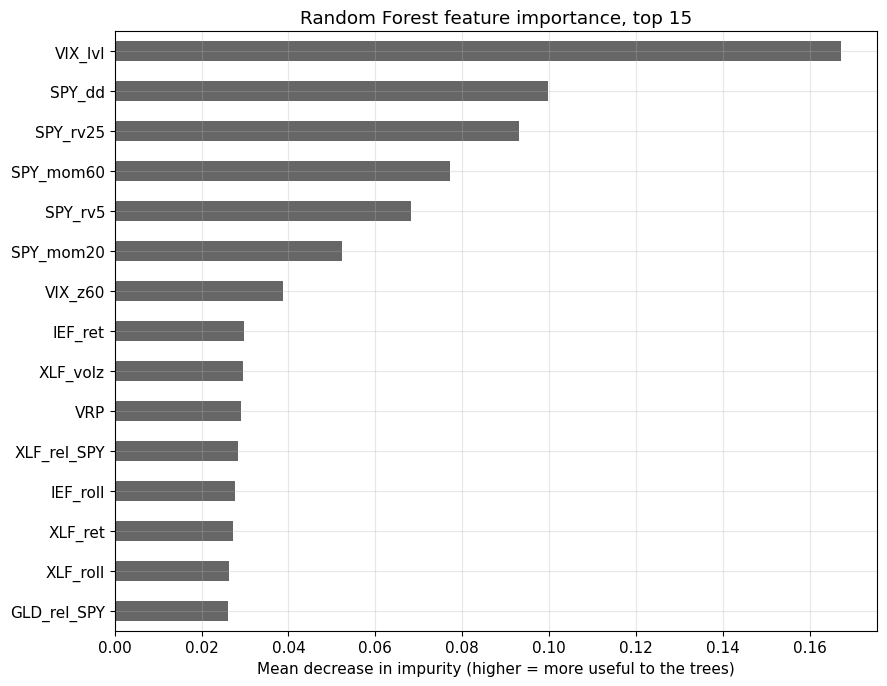

In [29]:
# ============================================================================
# Feature importance from the Random Forest: how much each feature helped the
# trees separate drop days from calm days, averaged across the forest.
# Speaks to Gate 1 (are the features informative), not Gate 2 (already settled).
# ============================================================================

imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

print('Top 10 features by importance:')
print(imp.head(10).round(4).to_string())

# Greyscale bar chart for print. Plotted low-to-high so the largest sits at top.
fig, ax = plt.subplots(figsize=(9, 7))
imp.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='0.4')
ax.set_xlabel('Mean decrease in impurity (higher = more useful to the trees)')
ax.set_title('Random Forest feature importance, top 15')
plt.tight_layout()
plt.show()

The top of the ranking is a list of features with an obvious reason to predict a drop, which is what Gate 1 asks for.

- **VIX_lvl (0.167):** the level of the VIX, by a wide margin the most-used feature. The VIX rises when option markets expect large moves, so a high VIX marking a dangerous day is exactly what we would hope to see.
- **SPY_dd (0.100):** how far SPY sits below its recent high. Drops tend to arrive when the market is already falling, not at the top.
- **SPY_rv25 and SPY_rv5 (0.093, 0.068):** realized volatility over the last month and the last week. Turbulent stretches cluster, so recent volatility predicts more of it.
- **SPY_mom60 and SPY_mom20 (0.077, 0.052):** momentum over 60 and 20 days. Weak momentum lines up with the shaky periods where drops happen.
- **VIX_z60 (0.039):** the VIX measured against its own recent range, the stationary version we built for exactly this purpose.

Two things stand out. First, the model concentrated on volatility and trend, the features any experienced trader would reach for when judging near-term risk. It did not lean on the noise. That satisfies Gate 1: the features carry real information.

Second, and this is the thread that runs into the next section, six of the top seven features are measures of volatility, drawdown, or weak momentum. Every one of them describes how turbulent the market is right now. None of them describes which direction it is about to go. That distinction is easy to miss here, where it just looks like a sensible ranking, and it turns out to be the whole story of why this strategy does not work. The next section makes it visible.

## 10. What the model actually learned (Gate 4)

We know the model has real skill, and we know which features drive it. The question that decides whether it is worth trading is different: when the model says danger, what happens next?

To see it, we list every day the model was worried enough to go risk-off, meaning its probability crossed the 0.50 threshold. For each of those days we show two things:

- The VIX level that day, to confirm the model is reacting to real stress.
- The actual SPY return the next day, to see whether the drop it predicted arrived.

This connects to Gate 4 from Chapter 14, which asks whether you can afford not to understand what a model is doing. A list of the model's own decisions, with what followed each one, is the most direct way to understand it. If the flagged days are followed by drops, the model is doing its job. If they are followed by a mix of drops and sharp rebounds, the model is reacting to something real but not to what we assumed.

In [30]:
# ============================================================================
# List every day the model went risk-off (probability >= RISK_OFF) with the VIX
# level and the actual next-day SPY return. This is the clearest single view of
# what the model learned, and it drives the Gate 4 reading.
# ============================================================================

spy_ret  = feat_px['SPY'].pct_change()
rf_probs = probs['rf']

def exit_table(prob_series, risk_off):
    """Every day the model's probability crossed risk_off, with what came next."""
    off = prob_series.index[prob_series >= risk_off]
    rows = []
    for d in off:
        nxt = spy_ret.loc[spy_ret.index > d]   # the next trading day's SPY return
        rows.append({'date': d.date(),
                     'VIX': round(feat_px['VIX'].loc[d], 1),
                     'next_day_SPY': round(nxt.iloc[0], 4) if len(nxt) else np.nan})
    t = pd.DataFrame(rows)
    hit = int((t['next_day_SPY'] < THRESHOLD).sum())
    print(f'Threshold {risk_off}: {len(t)} risk-off days, '
          f'{hit} followed by a {THRESHOLD:.0%} drop '
          f'({hit/len(t):.0%} hit rate, base rate {y_test.mean():.0%})')
    return t

exits_50 = exit_table(rf_probs, RISK_OFF)
exits_50

Threshold 0.5: 126 risk-off days, 24 followed by a -2% drop (19% hit rate, base rate 4%)


,date,VIX,next_day_SPY
0,2020-02-26,27.6,-0.0449
1,2020-03-02,33.4,-0.0286
2,2020-03-03,36.8,0.0420
3,2020-03-04,32.0,-0.0332
4,2020-03-05,39.6,-0.0165
...,...,...,...
121,2025-04-29,24.2,0.0004
122,2025-04-30,24.7,0.0071
123,2025-05-05,23.6,-0.0083
124,2025-05-06,24.8,0.0042


The summary line is the finding, so read it before the table.

- **126 risk-off days** at the 0.50 threshold.
- **24 of them** were followed by an actual 2% drop.
- **19% hit rate**, against a base rate of 4%.

Two readings pull in opposite directions, and both are true.

The model has real skill. A 19% hit rate against a 4% base rate means its risk-off days are followed by a drop nearly five times as often as an average day. That matches the lift we measured in section 8. Every flagged day also lands on a high-VIX day, and the dates cluster on genuine stress: the COVID crash in early 2020, the 2022 decline, the April 2025 selloff. The model is not reacting to noise. It is reacting to real turbulence.

The model is also wrong most of the time. Of the 126 days it went risk-off, 102 were not followed by the drop it was signalling. Look at the third row: 2020-03-03, VIX at 36.8, the model goes risk-off, and SPY rises 4.20% the next day. That is not a fluke in the data. It is the pattern. The flagged days are followed by large moves, and those moves go up about as often as they go down.

This is the heart of what the model learned, and section 9 set it up. Six of the top seven features measure how turbulent the market is, and none of them measures direction. So the model learned to identify turbulent days accurately, and turbulent days are followed by large moves in both directions. A high VIX predicts the size of tomorrow's move. It does not predict the sign.

That distinction decides the strategy. De-risking on these signals means selling ahead of the rebounds as often as ahead of the drops. It is also why every model agreed: the limitation is in what the features can predict, not in whether we used a straight line or a tree. This is Gate 4's answer. Understanding what the model does is not optional here, because the exit list is what reveals that the signal, real as it is, is the wrong kind of signal to trade this way.

## 11. From probabilities to weights (the naive version first)

The model produces a probability each day. To trade it, we turn that probability into a portfolio allocation. The backtest harness from *Chapter 13* takes a sparse weights file, one row per change in allocation, and runs a costed backtest against a benchmark.

The rule we use is a partial de-risk with a multi-day hold:

- Hold 100% SPY by default.
- When the Random Forest probability crosses `RISK_OFF` (0.50), cut SPY to `SPY_WEIGHT_OFF` (60%) and put the rest in IEF.
- Hold that de-risked stance for `HOLD_DAYS` (5 days), then restore full SPY.

This is deliberately the second version, not the first. An all-or-nothing rule that sells everything on each signal and buys back the next day generates a great deal of trading, and the cost of that trading is a lesson in itself. The chapter shows that naive version failing before this one, so the reason for the partial de-risk and the multi-day hold is earned rather than asserted. We build the partial version here because it is what the backtest scores, and the naive comparison sits in the chapter text alongside it.

In [31]:
# ============================================================================
# Turn the model's probabilities into a sparse SPY/IEF weights file.
# Default 100% SPY. On a risk-off signal, cut SPY to spy_off for hold_days,
# then restore. Sparse: one row only when the allocation changes.
# ============================================================================

def build_weights(prob_series, risk_off, hold_days, spy_off):
    """Sparse SPY/IEF weights. Trip to spy_off on a signal, hold, then restore."""
    sig  = (prob_series >= risk_off).astype(int)
    # A signal on any of the last `hold_days` keeps the position de-risked,
    # so a cluster of signals does not cause repeated in-and-out trading.
    held = sig.rolling(hold_days, min_periods=1).max().fillna(0).astype(int)
    spy  = np.where(held == 1, spy_off, 1.0)
    alloc = pd.DataFrame({'SPY': spy, 'IEF': 1.0 - spy}, index=prob_series.index)
    # Keep only the rows where the allocation actually changes: the sparse contract.
    changed = (alloc != alloc.shift()).any(axis=1)
    changed.iloc[0] = True
    out = alloc.loc[changed]
    out.index.name = 'Date'
    return out

w = build_weights(rf_probs, RISK_OFF, HOLD_DAYS, SPY_WEIGHT_OFF)
w.to_csv('weights_rf_partial.csv')

print(f'{len(w)} weight rows, {(w["SPY"] < 1.0).sum()} de-risked periods')
w.head()

31 weight rows, 15 de-risked periods


,SPY,IEF
Date,,
2019-01-02,1.0,0.0
2020-02-26,0.6,0.4
2020-05-20,1.0,0.0
2020-06-11,0.6,0.4
2020-06-18,1.0,0.0


The weights file is short, which is the point of the sparse contract.

- **31 rows** over seven and a half years, one for each time the allocation changes.
- **15 de-risked periods**, where SPY was cut to 60% and 40% moved to IEF.
- The first row is 2019-01-02 at full SPY, the default stance the strategy holds whenever the model is not signalling danger.

Read the first few rows to see the rule working. The strategy sits at 100% SPY until 2020-02-26, when the model crosses the risk-off threshold as the COVID selloff begins, and SPY is cut to 60%. It restores to full SPY on 2020-05-20, then de-risks again on 2020-06-11, and so on. Each de-risked period lasts the five-day hold set in the parameters, extended when fresh signals keep arriving.

Between the dated rows, nothing happens: the harness reads the gaps as "hold", and the position rides the market until the next change. This is what keeps the strategy from trading every day. The next section runs this weights file through the backtest and, more importantly, sets it against a benchmark that uses no model at all.

## 12. The naive rule: a full sweep (Gate 4, before the fix)

Section 11 built one specific trading rule: partial de-risking, a
five-day hold, 60% of the position kept in SPY even on a signal. Before
trusting that specific choice, it is worth testing the simpler version
first, an all-or-nothing exit to IEF, held for exactly one day, using
the same `build_weights` function with `hold_days=1` and `spy_off=0.0`.
Swept across several thresholds rather than tested at just one, since
the goal is to see how sensitive this naive version is to the threshold
chosen, and to have a real number to compare the fix in Section 11
against.

In [32]:
naive_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
naive_rows = []

from vectorbt_harness_no_yf import run_backtest

for thresh in naive_thresholds:
    w_naive = build_weights(rf_probs, thresh, hold_days=1, spy_off=0.0)
    fn = f'weights_naive_{int(thresh*100)}.csv'
    w_naive.to_csv(fn)
    res = run_backtest(fn, bt_prices, benchmark='SPY', verbose=False)
    n_trades = len(w_naive) - 1

    naive_rows.append({
        'threshold': thresh,
        'n_trades': n_trades,
        'CAGR_after_costs': res.metrics.loc['Ann. Return (CAGR)', 'Strategy w/ Costs'],
        'Sharpe_after_costs': res.metrics.loc['Sharpe Ratio', 'Strategy w/ Costs'],
        'MaxDD_after_costs': res.metrics.loc['Max Drawdown', 'Strategy w/ Costs'],
    })

naive_df = pd.DataFrame(naive_rows)
naive_df

,threshold,n_trades,CAGR_after_costs,Sharpe_after_costs,MaxDD_after_costs
0,0.30,207,-0.08%,-0.006,-34.58%
1,0.35,197,1.71%,0.115,-32.56%
2,0.40,151,5.33%,0.364,-35.88%
3,0.45,117,7.05%,0.439,-43.13%
4,0.50,62,13.01%,0.856,-30.11%
5,0.55,44,10.43%,0.629,-42.38%
6,0.60,32,11.12%,0.656,-31.51%


The naive rule loses at every threshold tested, and not narrowly. Its
best result comes at 0.50, the same threshold used everywhere else in
this notebook: 62 trades, a 13.01% CAGR after costs, a Sharpe ratio of
0.856. Its worst comes at the most aggressive setting, 0.30: 207 trades
and a CAGR of essentially zero, -0.08% after costs. Every configuration
also posts a deeper maximum drawdown than plain SPY, ranging from
-30.11% at best to -43.13% at worst, despite drawdown protection being
the entire point of the rule.

The relationship between trade count and performance is not perfectly
clean either. Results improve steadily from 0.30 up through 0.50, then
turn noisy: 0.55 trades less often than 0.45 but performs worse, and
worse again than the more conservative 0.60.

This sets up the fix tested in Section 11: not a different signal,
trading the same signal less often.

## 13. Backtest against the static benchmark (the verdict)

Every result so far has been about prediction: can the model rank dangerous days above calm ones? It can. This section asks the only question that decides whether the model is worth using: does trading on it beat a simpler approach that uses no model at all?

We score three things and set them side by side:

- **The RF strategy:** the weights from the previous section, run through the backtest with trading costs applied.
- **A constant SPY/IEF blend:** the same two assets the strategy holds, but at a fixed split that never changes, with no model and no signal. We try three splits, 85/15, 88/12, and 90/10.
- **SPY buy-and-hold:** 100% SPY, the plainest benchmark of all.

The constant blend is the comparison that matters, and it is worth being clear about why. The RF strategy spends most of its time at 100% SPY and occasionally shifts to 60% SPY, 40% IEF. On average, then, it holds a bit less SPY and a bit more IEF than buy-and-hold. A constant blend that holds that same average split, all the time, captures the de-risking without the model. If the blend matches the strategy, then the features, the tree, the threshold, and the hold rule have together produced nothing that a single fixed number could not.

This mirrors a benchmark used elsewhere in the book: when testing whether a stock-picking rule adds value, you compare it against simply holding all the stocks equally weighted. Here the equivalent is holding the two assets at a fixed split. It is the fair bar, and it is a hard one to clear.

In [33]:
# ============================================================================
# Backtest three things: the RF strategy, a constant SPY/IEF blend at several
# splits, and SPY buy-and-hold. The constant blend is the fair benchmark: the
# same two assets, held at a fixed split, with no model and no signal.
# ============================================================================

from vectorbt_harness_no_yf import run_backtest

results = {}

# The model strategy: the sparse weights we built in the previous section.
results['RF partial'] = run_backtest('weights_rf_partial.csv', bt_prices,
                                     benchmark='SPY', verbose=False)

# The constant-allocation benchmarks. One dated row each, so the blend is set
# once and held for the whole period, which is what "no model, no signal" means.
for sw in STATIC_WEIGHTS:
    sdf = pd.DataFrame({'SPY': [sw], 'IEF': [1 - sw]}, index=[rf_probs.index[0]])
    sdf.index.name = 'Date'
    fn = f'weights_static_spy{int(sw*100)}.csv'
    sdf.to_csv(fn)
    results[f'static {int(sw*100)}/{int((1-sw)*100)}'] = run_backtest(
        fn, bt_prices, benchmark='SPY', verbose=False)

# Pull the same five metrics from each result, from the costed strategy column.
KEYS = ['Ann. Return (CAGR)', 'Ann. Volatility', 'Max Drawdown',
        'Sharpe Ratio', 'Calmar Ratio']
table = {name: {k: res.metrics.loc[k, 'Strategy w/ Costs'] for k in KEYS}
         for name, res in results.items()}

# SPY buy-and-hold comes from the benchmark column, which every run shares.
table['SPY B&H'] = {k: results['RF partial'].metrics.loc[k, 'SPY Buy & Hold']
                    for k in KEYS}

pd.DataFrame(table).T

,Ann. Return (CAGR),Ann. Volatility,Max Drawdown,Sharpe Ratio,Calmar Ratio
RF partial,15.18%,14.60%,-25.84%,1.040,0.588
static 85/15,15.51%,14.73%,-22.88%,1.053,0.678
static 88/12,16.04%,15.23%,-23.20%,1.053,0.691
static 90/9,16.29%,15.48%,-23.36%,1.052,0.698
SPY B&H,17.43%,16.62%,-23.93%,1.049,0.728


Read the table by comparing the RF strategy against the static 85/15 blend, since that is the fair test.

- **CAGR:** static 85/15 returns 15.51% a year against the RF strategy's 15.18%, so the blend wins.
- **Max drawdown:** static 85/15 falls 22.88% at its worst against the RF strategy's 25.84%, so the blend wins by a wide margin, even though limiting drawdowns was the entire purpose of the model.
- **Sharpe ratio:** static 85/15 scores 1.053 against the RF strategy's 1.040, so the blend wins here too.

The static blend beats the model strategy on return, on drawdown, and on risk-adjusted return all at once, and it does this with no model, no features, no probability threshold, and no maintenance, as one fixed number held for seven and a half years.

Look at what the model strategy actually delivered. It gave up return against buy-and-hold, 15.18% versus 17.43%, which is expected, since holding some IEF instead of SPY lowers returns in a rising market, and in exchange it was supposed to lower risk. It did lower volatility, but its drawdown came out worse than plain SPY, 25.84% against 23.93%, so the one thing the model was built to do, protect against sharp declines, it did not do, for the reason section 10 already gave: it de-risked ahead of rebounds as often as ahead of drops.

Now compare the two ways of holding less SPY. Both the model strategy and the static blend end up holding a mix of SPY and IEF, but the blend does it at a fixed split while the model does it by trying to time the shifts, and the fixed split produced the better result on every metric. All the timing added was cost and worse drawdowns, and it subtracted nothing from the risk in return.

**Gate 4, and the closing argument.** Gate 4 asks whether you can afford not to understand a model, and here understanding it is what settles the case. The model holds a mix of a risky asset and a safe one, and mixing those two moves a portfolio along the risk-return line, trading return for lower risk in fixed proportion. A constant blend does exactly that cleanly, while the model does the same thing less well, because its timing adds cost and its signal cannot tell an upcoming drop from an upcoming rebound. It sits on the same risk-return line as the blend, slightly below it, and nothing in the 23 features, the tuned tree, the threshold, or the hold rule moved the portfolio off that line.

That is the chapter, because every gate pointed the same way. Gate 1 found real, usable information in the features, and Gate 2 found that the information was linear, confirmed three times over. Gate 3 warned that 73 test events was a thin base to trust, and Gate 4 showed that even the model's real skill bought nothing a fixed number could not. The process did its job: it told us the answer was no before a dollar was at risk, which is exactly what a disciplined process is for. A model finding real signal and still losing to a simpler approach is not a failure of the method, it is the method working.

## 14. Equity curve

The table gave the verdict in numbers. A chart makes it visible. This plots the RF strategy's growth over the test period against SPY buy-and-hold, both with costs applied, so you can see where the strategy fell behind and where its de-risking helped or hurt.

Watch three stretches as you read it:

- **Early 2020, the COVID crash:** the model was active here, cutting SPY as volatility spiked. See whether the de-risking softened the fall or missed the sharp rebound that followed.
- **The 2022 decline:** a slower, grinding drop rather than a single crash. See whether a model tuned to spot 2% down days did anything useful in a market that fell gradually.
- **The long stretches in between:** where the model sat at full SPY and simply tracked the benchmark, minus the cost of its occasional trades.

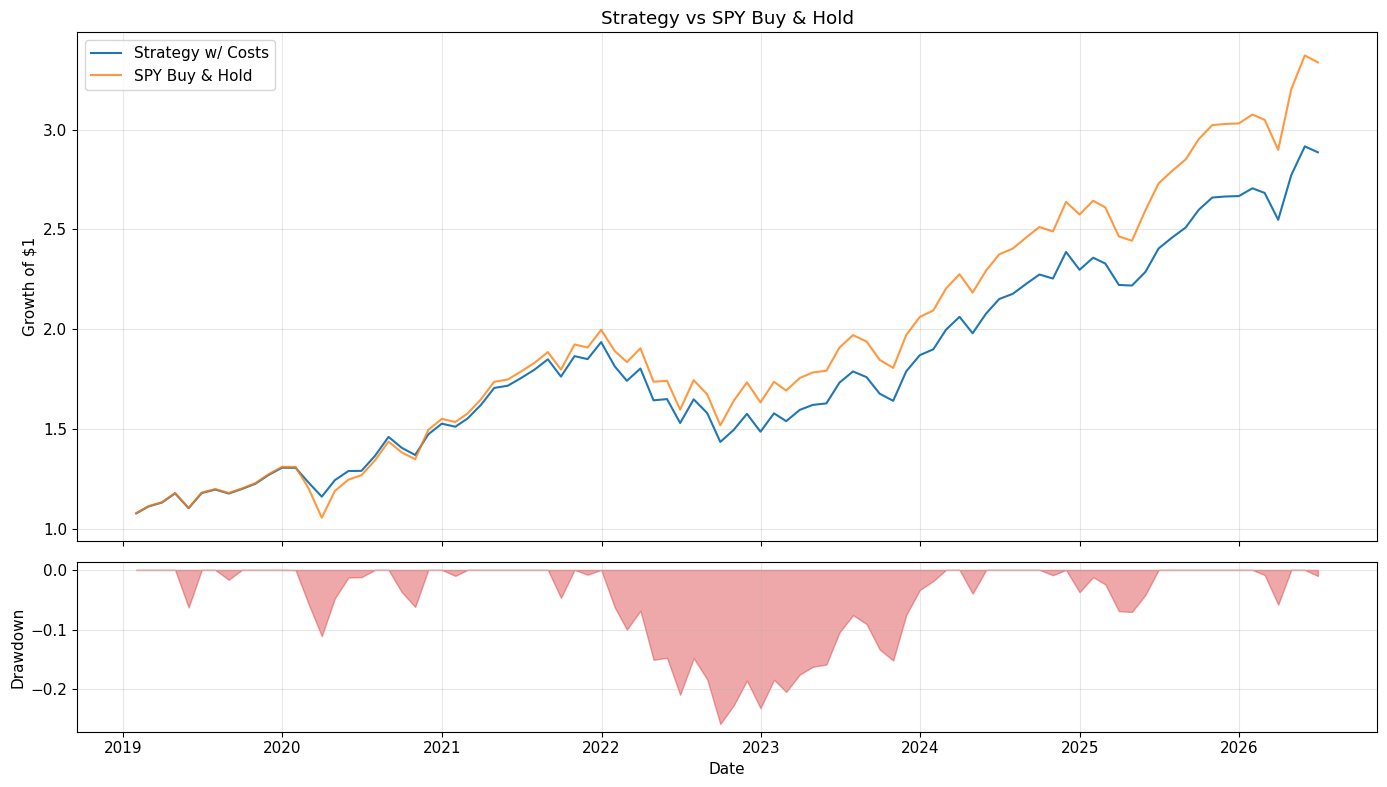

In [34]:
# ============================================================================
# Equity curve: the RF strategy against SPY buy-and-hold, both costed, over the
# test period. The plot is the table's verdict in visual form.
# ============================================================================

_ = results['RF partial'].plot(use_costs=True)